In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, LogisticRegression


In [103]:
df = pd.read_csv('/content/train.csv')

In [104]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [105]:
df.shape



(9800, 18)

In [106]:
df.dtypes


,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [107]:

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [108]:

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')



In [109]:
# Create temporal features
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days



In [110]:
df


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Month,Order_Year,Ship_Days
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,8.0,2017.0,92.0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,8.0,2017.0,92.0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12.0,2017.0,NaN
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11.0,2016.0,NaN
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11.0,2016.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,NaT,NaT,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,NaN,NaN,NaN
9796,9797,CA-2016-128608,2016-12-01,NaT,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,12.0,2016.0,NaN
9797,9798,CA-2016-128608,2016-12-01,NaT,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,12.0,2016.0,NaN
9798,9799,CA-2016-128608,2016-12-01,NaT,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,12.0,2016.0,NaN


In [111]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,5841
Ship Date,5985
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [112]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order_Month,Order_Year,Ship_Days
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,8.0,2017.0,92.0
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,8.0,2017.0,92.0
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,12.0,2017.0,NaN
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,11.0,2016.0,NaN
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,11.0,2016.0,NaN


In [113]:
# Replace negative Ship_Days with NaN and fill missing values with median
df.loc[df['Ship_Days'] < 0, 'Ship_Days'] = np.nan
df['Ship_Days'] = df['Ship_Days'].fillna(df['Ship_Days'].median())

<Axes: >

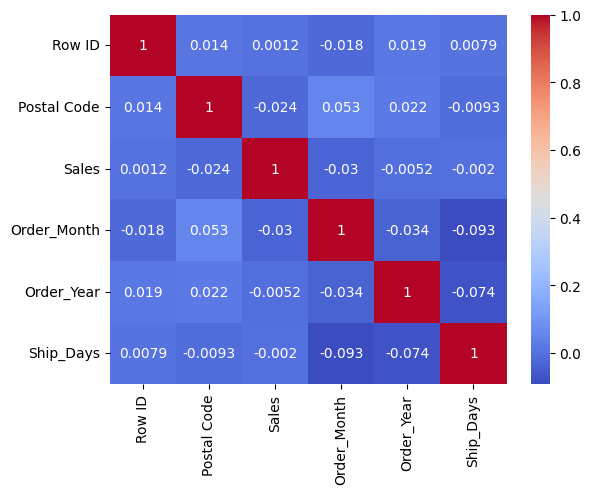

In [114]:
sns.heatmap(df.corr( numeric_only = True) ,annot = True, cmap= 'coolwarm')

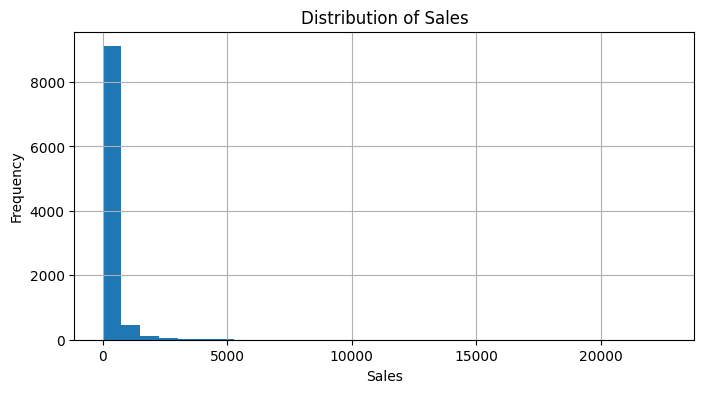

In [115]:
# Distribution of Sales
plt.figure(figsize=(8,4))
df['Sales'].hist(bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

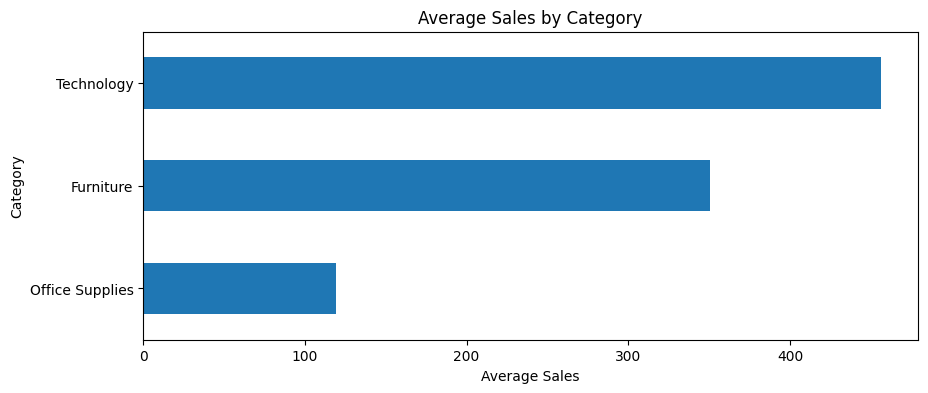

In [116]:
# Average Sales by Category
plt.figure(figsize=(10,4))
category_sales = df.groupby('Category')['Sales'].mean().sort_values()
category_sales.plot(kind='barh')
plt.title('Average Sales by Category')
plt.xlabel('Average Sales')
plt.ylabel('Category')
plt.show()

In [117]:
# Drop irrelevant columns
drop_cols = ['Row ID','Order ID','Customer ID','Customer Name',
             'Product ID','Product Name','Order Date','Ship Date',
             'Country','City','State','Postal Code','Profit']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])



In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the processed dataframe for label encoding
df_label = df.copy()

# Create binary classification target based on median sales
median_sales = df_label['Sales'].median()
df_label['High_Sales'] = (df_label['Sales'] > median_sales).astype(int)

# Identify categorical columns
categorical_cols = df_label.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    label_encoders[col] = le

# Features and target for classification
X= df_label.drop(columns=['Sales','High_Sales'])
y_clf= df_label['High_Sales']

In [119]:
# Create binary classification target based on median sales
median_sales = df['Sales'].median()
df['High_Sales'] = (df['Sales'] > median_sales).astype(int)

In [120]:
# Define targets
y_reg = df['Sales']
y_clf = df['High_Sales']

# Create feature matrix
df_features = df.drop(columns=['Sales','High_Sales'])
# One-hot encode categorical variables
df_features = pd.get_dummies(df_features, drop_first=True)

# Final feature matrix
X = df_features

In [129]:
df.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Order_Month,Order_Year,Ship_Days,High_Sales
0,2,0,2,0,4,261.9600,8.0,2017.0,92.0,1
1,2,0,2,0,5,731.9400,8.0,2017.0,92.0,1
2,2,1,3,1,10,14.6200,12.0,2017.0,122.0,0
3,3,0,2,0,16,957.5775,11.0,2016.0,122.0,1
4,3,0,2,1,14,22.3680,11.0,2016.0,122.0,0


In [121]:
# Split data into train and test sets
# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
# Classification split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)


In [122]:
import numpy as np

# Linear Regression Model
lr_model = LinearRegression()

# Fit model on full training data without dropping rows (missing values assumed handled in preprocessing)
lr_model.fit(X_train_reg, y_train_reg)

# Predict on the test set
lr_pred = lr_model.predict(X_test_reg)


In [123]:
lr_model.score(X_test_reg,y_test_reg)

0.003808461395568563

In [124]:
# Split data into train and test sets
# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
# Classification split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

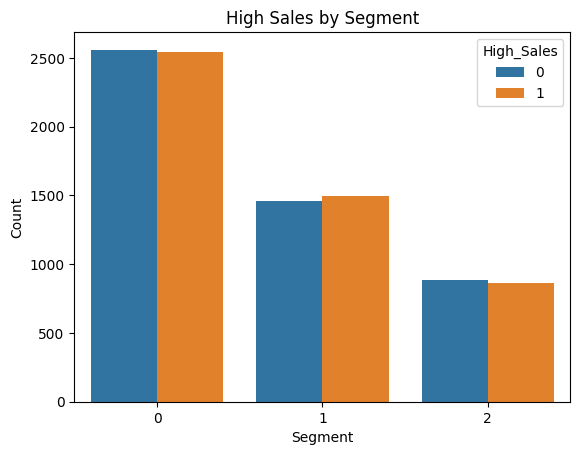

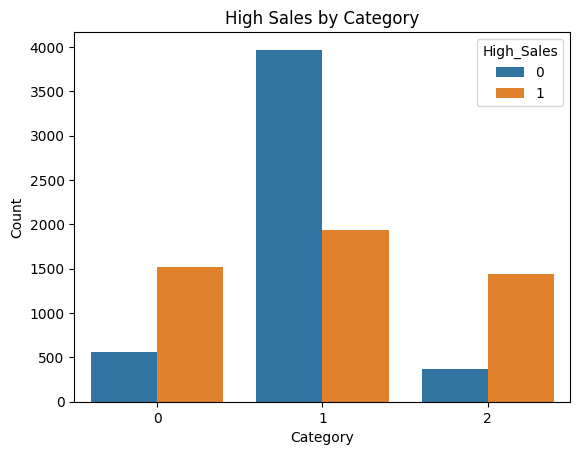

In [125]:
sns.countplot(x='Segment', hue='High_Sales', data=df)
plt.title('High Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

# You can repeat similar plots for other categorical variables such as Category
sns.countplot(x='Category', hue='High_Sales', data=df)
plt.title('High Sales by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


In [ ]:

from sklearn.preprocessing import LabelEncoder

# Make a copy of the processed dataframe
df_label = df.copy()

# Identify categorical columns
categorical_cols = df_label.select_dtypes(include=['object']).columns

# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    label_encoders[col] = le

# Features and target for classification
X_le = df_label.drop(columns=['Sales','High_Sales'])
y_clf_le = df_label['High_Sales']

In [127]:
df_label.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Order_Month,Order_Year,Ship_Days,High_Sales
0,2,0,2,0,4,261.9600,8.0,2017.0,92.0,1
1,2,0,2,0,5,731.9400,8.0,2017.0,92.0,1
2,2,1,3,1,10,14.6200,12.0,2017.0,122.0,0
3,3,0,2,0,16,957.5775,11.0,2016.0,122.0,1
4,3,0,2,1,14,22.3680,11.0,2016.0,122.0,0


In [128]:
# Removed car dataset get_dummies cell
# This cell is not relevant for the sales dataset
df.head()


KeyError: "None of [Index(['fueltype', 'carbody', 'carbrand'], dtype='object')] are in the [columns]"

In [ ]:
# Split the data
X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(
    X_le, y_clf_le, test_size=0.2, random_state=42)



# Train the logistic regression model
log_model_le = LogisticRegression(max_iter=1000)
log_model_le.fit(X_train_le, y_train_le)

# Make predictions
log_pred_le = log_model_le.predict(X_test_le)

# Evaluation metrics
acc_le = np.mean((y_test_le == log_pred_le))
conf_matrix = pd.crosstab(y_test_le, log_pred_le, rownames=['Actual'], colnames=['Predicted'])
print('Accuracy:', acc_le)
print(conf_matrix)


In [ ]:
log_model_le.score(X_test_le,y_test_le)